In this notebook, we will be applying different filters on the data, determine which is the best and see if we can see noticible changes in the data.

## 1. Setup and Imports

In [47]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq

# Make project root importable whether CWD is repo root or notebooks/
cwd = Path.cwd()
PROJECT_ROOT = cwd if (cwd / 'src').exists() else cwd.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.labels import plot_labeled_sensors, plot_labeled_acc, plot_labeled_gyro, plot_labeled_odo

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis


In [48]:
# Load the cleaned dataset
cleaned_path = PROJECT_ROOT / "data" / "interim" / "cleaned" / "cleaned_dataset.csv"

if not cleaned_path.exists():
    raise FileNotFoundError(f"Cleaned dataset not found: {cleaned_path}\nPlease run 04_cleaning.ipynb first.")

df = pd.read_csv(cleaned_path)

# Ensure label column is properly typed
df['label'] = df['label'].astype('string').str.strip()

print(f"Loaded cleaned dataset: {cleaned_path}")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Unique run_ids: {df['run_id'].nunique()}")
print(f"\nLabel distribution:")
print(df['label'].value_counts())
print(f"\nRun IDs:")
for run_id in sorted(df['run_id'].unique()):
    n_samples = len(df[df['run_id'] == run_id])
    duration = df[df['run_id'] == run_id]['t_rel'].max() - df[df['run_id'] == run_id]['t_rel'].min()
    print(f"  - {run_id}: {n_samples} samples ({duration:.2f} seconds)")

Loaded cleaned dataset: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/data/interim/cleaned/cleaned_dataset.csv
Shape: (53670, 14)
Columns: ['t', 't_rel', 'run_id', 'ax', 'ay', 'az', 'gx', 'gy', 'gz', 'v1', 'v2', 'label', 'net_speed', 'yaw_rate']
Unique run_ids: 2

Label distribution:
label
smooth_terrain      24345
muddy_dirt_track    18972
grass               10353
Name: count, dtype: Int64

Run IDs:
  - log_20260223_142511.490: 36684 samples (537.34 seconds)
  - log_20260226_102148.990: 16986 samples (554.73 seconds)


In [49]:
# Define sensor columns for filtering
sensor_columns = {
    'accelerometer': ['ax', 'ay', 'az'],
    'gyroscope': ['gx', 'gy', 'gz'],
    'odometry': ['v1', 'v2', 'net_speed', 'yaw_rate']
}

all_sensor_cols = [col for cols in sensor_columns.values() for col in cols]
print(f"Sensor columns to filter: {all_sensor_cols}")

# Sampling rate
SAMPLE_RATE = 100  # Hz
SAMPLE_PERIOD = 1.0 / SAMPLE_RATE  # seconds

Sensor columns to filter: ['ax', 'ay', 'az', 'gx', 'gy', 'gz', 'v1', 'v2', 'net_speed', 'yaw_rate']


In [50]:
# Gap detection threshold for identifying continuous segments
GAP_THRESHOLD = 0.025  # seconds (2.5x sample period)

def detect_continuous_segments(df, gap_threshold):
    """
    Detect continuous segments within each run, identifying time gaps.
    
    Args:
        df: DataFrame with 'run_id' and 't_rel' columns
        gap_threshold: Maximum allowed time gap (seconds) between consecutive samples
        
    Returns:
        List of segment dictionaries with keys:
            - run_id: Run identifier
            - segment_id: Segment number within run (0-indexed)
            - indices: Index values for this segment
            - start_time: First timestamp
            - end_time: Last timestamp
            - n_samples: Number of samples in segment
    """
    segments = []
    
    for run_id in sorted(df['run_id'].unique()):
        run_mask = df['run_id'] == run_id
        run_data = df[run_mask].sort_values('t_rel').copy()
        
        # Calculate time differences between consecutive samples
        time_diff = run_data['t_rel'].diff()
        
        # Find gaps (where time_diff > threshold)
        gap_mask = time_diff > gap_threshold
        gap_indices = np.where(gap_mask)[0]
        
        # Create segments
        segment_id = 0
        start_idx = 0
        
        for gap_idx in gap_indices:
            # Segment before the gap
            segment_indices = run_data.index[start_idx:gap_idx]
            if len(segment_indices) > 0:
                segments.append({
                    'run_id': run_id,
                    'segment_id': segment_id,
                    'indices': segment_indices.tolist(),
                    'start_time': run_data.iloc[start_idx]['t_rel'],
                    'end_time': run_data.iloc[gap_idx-1]['t_rel'],
                    'n_samples': len(segment_indices)
                })
                segment_id += 1
            start_idx = gap_idx
        
        # Last segment
        segment_indices = run_data.index[start_idx:]
        if len(segment_indices) > 0:
            segments.append({
                'run_id': run_id,
                'segment_id': segment_id,
                'indices': segment_indices.tolist(),
                'start_time': run_data.iloc[start_idx]['t_rel'],
                'end_time': run_data.iloc[-1]['t_rel'],
                'n_samples': len(segment_indices)
            })
    
    return segments

print(f"Gap detection configured: GAP_THRESHOLD = {GAP_THRESHOLD} seconds")
print(f"  (= {GAP_THRESHOLD/SAMPLE_PERIOD:.1f}x sample period)")

Gap detection configured: GAP_THRESHOLD = 0.025 seconds
  (= 2.5x sample period)


## 2. Frequency Analysis

Before applying filters, let's analyze the frequency content of our sensor signals to understand:
1. What frequency ranges contain actual signal (terrain-related vibrations)
2. What frequency ranges contain noise
3. Appropriate cutoff frequencies for lowpass filters

In [51]:
def compute_psd(signal_data, sample_rate):
    """
    Compute Power Spectral Density using FFT.
    
    Args:
        signal_data: 1D numpy array of signal values
        sample_rate: Sampling rate in Hz
        
    Returns:
        frequencies: Frequency values (Hz)
        psd: Power spectral density
    """
    n = len(signal_data)
    # Remove DC component (mean)
    signal_centered = signal_data - np.mean(signal_data)
    
    # Compute FFT
    fft_vals = fft(signal_centered)
    freqs = fftfreq(n, 1/sample_rate)
    
    # Only positive frequencies
    positive_mask = freqs > 0
    freqs = freqs[positive_mask]
    
    # Compute power spectral density
    psd = 2.0 * np.abs(fft_vals[positive_mask])**2 / n
    
    return freqs, psd

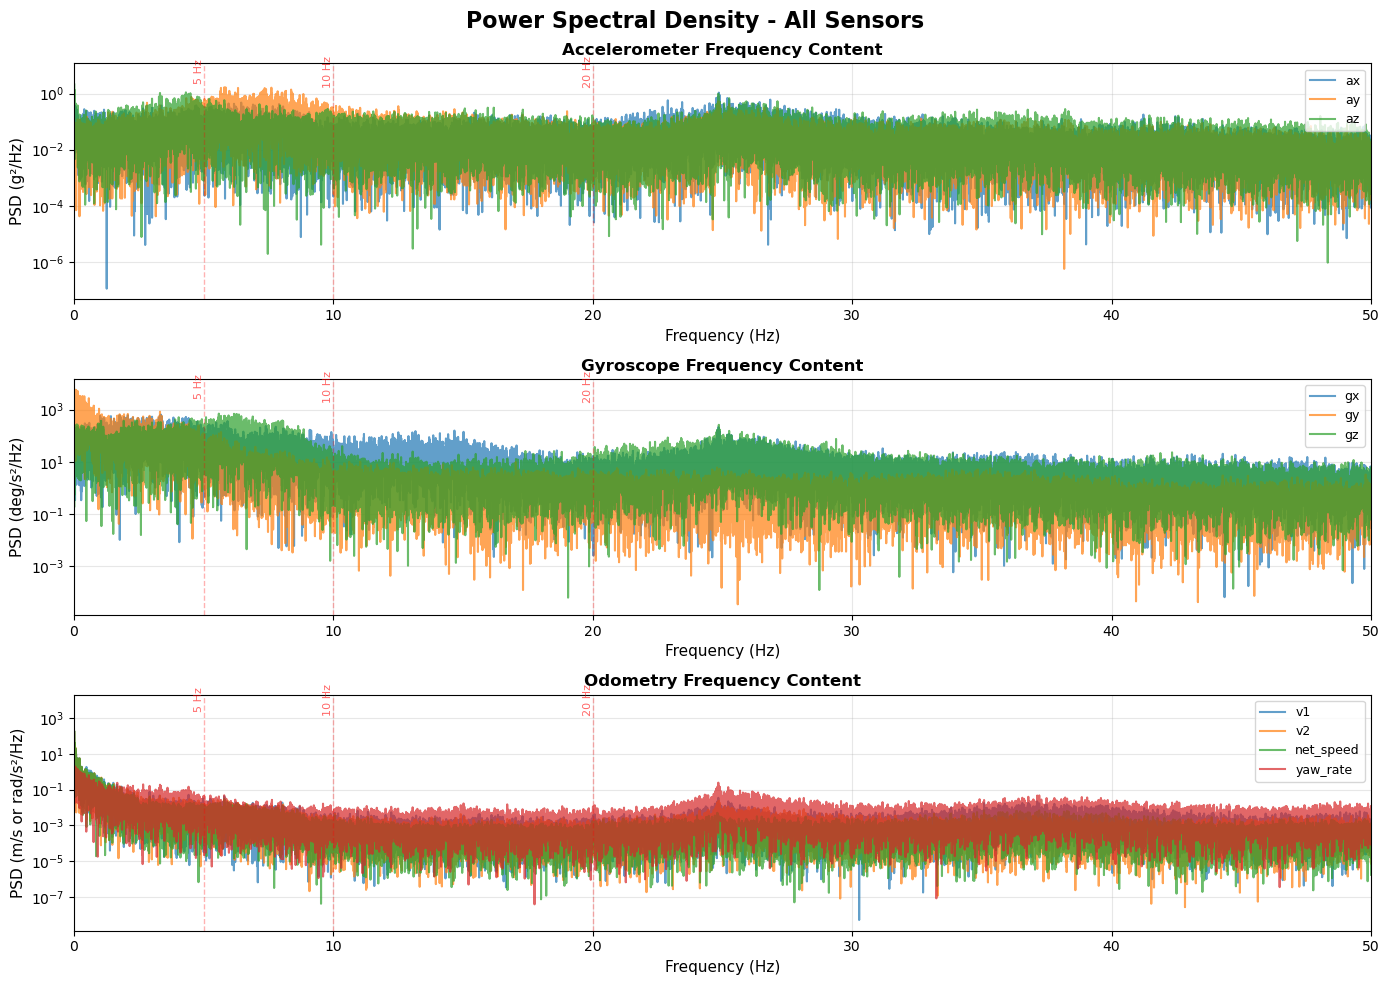

Interpretation:
- High power at low frequencies (<5 Hz): Robot motion and terrain features
- Power at mid frequencies (5-20 Hz): Terrain-induced vibrations
- Power at high frequencies (>20 Hz): Sensor noise and high-frequency vibrations
- Red dashed lines show candidate cutoff frequencies for lowpass filters


In [52]:
# Compute PSD for each sensor channel across all data
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle('Power Spectral Density - All Sensors', fontsize=16, fontweight='bold')

sensor_groups = [
    ('Accelerometer', sensor_columns['accelerometer'], 'g'),
    ('Gyroscope', sensor_columns['gyroscope'], 'deg/s'),
    ('Odometry', sensor_columns['odometry'], 'm/s or rad/s')
]

for idx, (group_name, cols, unit) in enumerate(sensor_groups):
    ax = axes[idx]
    
    for col in cols:
        # Concatenate all runs for this sensor
        signal_data = df[col].values
        freqs, psd = compute_psd(signal_data, SAMPLE_RATE)
        
        # Plot on log scale
        ax.semilogy(freqs, psd, label=col, alpha=0.7, linewidth=1.5)
    
    ax.set_xlabel('Frequency (Hz)', fontsize=11)
    ax.set_ylabel(f'PSD ({unit}²/Hz)', fontsize=11)
    ax.set_title(f'{group_name} Frequency Content', fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, SAMPLE_RATE/2])  # Nyquist frequency
    
    # Add reference lines for common cutoff frequencies
    for cutoff in [5, 10, 20]:
        ax.axvline(cutoff, color='red', linestyle='--', alpha=0.3, linewidth=1)
        ax.text(cutoff, ax.get_ylim()[1]*0.5, f'{cutoff} Hz', 
                rotation=90, va='center', ha='right', fontsize=8, color='red', alpha=0.6)

plt.tight_layout()
plt.show()

print("Interpretation:")
print("- High power at low frequencies (<5 Hz): Robot motion and terrain features")
print("- Power at mid frequencies (5-20 Hz): Terrain-induced vibrations")
print("- Power at high frequencies (>20 Hz): Sensor noise and high-frequency vibrations")
print("- Red dashed lines show candidate cutoff frequencies for lowpass filters")

## 3. Filter Implementation

We'll test three types of filters:
1. **Butterworth Lowpass**: Classic frequency-domain filter with smooth response
2. **Savitzky-Golay**: Polynomial fitting filter that preserves peaks/valleys
3. **Moving Average**: Simple smoothing filter

Each will be applied per-run to avoid artifacts at run boundaries.

In [53]:
def apply_butterworth_filter(data, cutoff_freq, sample_rate, order=4):
    """
    Apply Butterworth lowpass filter.
    
    Args:
        data: Input signal (1D array)
        cutoff_freq: Cutoff frequency in Hz
        sample_rate: Sampling rate in Hz
        order: Filter order (higher = sharper cutoff)
        
    Returns:
        Filtered signal
    """
    nyquist = sample_rate / 2
    normalized_cutoff = cutoff_freq / nyquist
    b, a = signal.butter(order, normalized_cutoff, btype='low', analog=False)
    filtered = signal.filtfilt(b, a, data)  # Zero-phase filtering
    return filtered


def apply_savgol_filter(data, window_length, polyorder=2):
    """
    Apply Savitzky-Golay smoothing filter.
    
    Args:
        data: Input signal (1D array)
        window_length: Length of the filter window (must be odd)
        polyorder: Order of the polynomial fit
        
    Returns:
        Filtered signal
    """
    if window_length % 2 == 0:
        window_length += 1  # Must be odd
    filtered = signal.savgol_filter(data, window_length, polyorder, mode='nearest')
    return filtered


def apply_moving_average(data, window_size):
    """
    Apply moving average filter.
    
    Args:
        data: Input signal (1D array)
        window_size: Size of the averaging window
        
    Returns:
        Filtered signal
    """
    kernel = np.ones(window_size) / window_size
    filtered = np.convolve(data, kernel, mode='same')
    return filtered


def apply_filter_to_dataframe(df, filter_func, filter_params, sensor_cols, segments):
    """
    Apply a filter to sensor columns, respecting continuous segment boundaries.
    
    Args:
        df: Input dataframe
        filter_func: Filter function to apply
        filter_params: Dictionary of parameters for the filter
        sensor_cols: List of column names to filter
        segments: List of segment dictionaries from detect_continuous_segments()
        
    Returns:
        Dataframe with filtered sensor columns
    """
    df_filtered = df.copy()
    
    for segment in segments:
        segment_indices = segment['indices']
        
        for col in sensor_cols:
            data = df.loc[segment_indices, col].values
            
            # Only filter if segment has enough samples
            if len(data) > 10:
                filtered = filter_func(data, **filter_params)
                df_filtered.loc[segment_indices, col] = filtered
    
    return df_filtered

print("Filter functions defined successfully!")
print("  - apply_filter_to_dataframe() now supports segment-based filtering")


Filter functions defined successfully!
  - apply_filter_to_dataframe() now supports segment-based filtering


In [54]:
# Define filter configurations to test
filter_configs = [
    # Butterworth filters with varying cutoffs and orders
    {
        'name': 'Butterworth_5Hz_order2',
        'func': apply_butterworth_filter,
        'params': {'cutoff_freq': 5, 'sample_rate': SAMPLE_RATE, 'order': 2},
        'description': 'Aggressive lowpass at 5 Hz, gentle rolloff'
    },
    {
        'name': 'Butterworth_5Hz_order4',
        'func': apply_butterworth_filter,
        'params': {'cutoff_freq': 5, 'sample_rate': SAMPLE_RATE, 'order': 4},
        'description': 'Aggressive lowpass at 5 Hz, sharp rolloff'
    },
    {
        'name': 'Butterworth_10Hz_order2',
        'func': apply_butterworth_filter,
        'params': {'cutoff_freq': 10, 'sample_rate': SAMPLE_RATE, 'order': 2},
        'description': 'Moderate lowpass at 10 Hz, gentle rolloff'
    },
    {
        'name': 'Butterworth_10Hz_order4',
        'func': apply_butterworth_filter,
        'params': {'cutoff_freq': 10, 'sample_rate': SAMPLE_RATE, 'order': 4},
        'description': 'Moderate lowpass at 10 Hz, sharp rolloff'
    },
    {
        'name': 'Butterworth_20Hz_order2',
        'func': apply_butterworth_filter,
        'params': {'cutoff_freq': 20, 'sample_rate': SAMPLE_RATE, 'order': 2},
        'description': 'Mild lowpass at 20 Hz, gentle rolloff'
    },
    
    # Savitzky-Golay filters with varying window sizes
    {
        'name': 'SavGol_win11_poly2',
        'func': apply_savgol_filter,
        'params': {'window_length': 11, 'polyorder': 2},
        'description': 'SG filter, 0.11s window (11 samples), quadratic fit'
    },
    {
        'name': 'SavGol_win21_poly2',
        'func': apply_savgol_filter,
        'params': {'window_length': 21, 'polyorder': 2},
        'description': 'SG filter, 0.21s window (21 samples), quadratic fit'
    },
    {
        'name': 'SavGol_win21_poly3',
        'func': apply_savgol_filter,
        'params': {'window_length': 21, 'polyorder': 3},
        'description': 'SG filter, 0.21s window (21 samples), cubic fit'
    },
    {
        'name': 'SavGol_win51_poly2',
        'func': apply_savgol_filter,
        'params': {'window_length': 51, 'polyorder': 2},
        'description': 'SG filter, 0.51s window (51 samples), quadratic fit'
    },
    
    # Moving average filters
    {
        'name': 'MovAvg_win5',
        'func': apply_moving_average,
        'params': {'window_size': 5},
        'description': 'Moving average, 0.05s window (5 samples)'
    },
    {
        'name': 'MovAvg_win11',
        'func': apply_moving_average,
        'params': {'window_size': 11},
        'description': 'Moving average, 0.11s window (11 samples)'
    },
    {
        'name': 'MovAvg_win21',
        'func': apply_moving_average,
        'params': {'window_size': 21},
        'description': 'Moving average, 0.21s window (21 samples)'
    },
]

print(f"Defined {len(filter_configs)} filter configurations:")
for i, cfg in enumerate(filter_configs, 1):
    print(f"{i:2d}. {cfg['name']:25s} - {cfg['description']}")

Defined 12 filter configurations:
 1. Butterworth_5Hz_order2    - Aggressive lowpass at 5 Hz, gentle rolloff
 2. Butterworth_5Hz_order4    - Aggressive lowpass at 5 Hz, sharp rolloff
 3. Butterworth_10Hz_order2   - Moderate lowpass at 10 Hz, gentle rolloff
 4. Butterworth_10Hz_order4   - Moderate lowpass at 10 Hz, sharp rolloff
 5. Butterworth_20Hz_order2   - Mild lowpass at 20 Hz, gentle rolloff
 6. SavGol_win11_poly2        - SG filter, 0.11s window (11 samples), quadratic fit
 7. SavGol_win21_poly2        - SG filter, 0.21s window (21 samples), quadratic fit
 8. SavGol_win21_poly3        - SG filter, 0.21s window (21 samples), cubic fit
 9. SavGol_win51_poly2        - SG filter, 0.51s window (51 samples), quadratic fit
10. MovAvg_win5               - Moving average, 0.05s window (5 samples)
11. MovAvg_win11              - Moving average, 0.11s window (11 samples)
12. MovAvg_win21              - Moving average, 0.21s window (21 samples)


In [55]:
# Detect continuous segments first
print("Detecting continuous segments in dataset...")
segments = detect_continuous_segments(df, GAP_THRESHOLD)

print(f"✓ Detected {len(segments)} continuous segments")
print()

# Print segment statistics per run
print("Segment Statistics:")
print("=" * 80)
for run_id in sorted(df['run_id'].unique()):
    run_segments = [s for s in segments if s['run_id'] == run_id]
    total_samples = sum(s['n_samples'] for s in run_segments)
    print(f"  {run_id}:")
    print(f"    - {len(run_segments)} segment(s), {total_samples} total samples")
    
    if len(run_segments) > 1:
        for seg in run_segments:
            duration = seg['end_time'] - seg['start_time']
            print(f"      • Segment {seg['segment_id']}: {seg['n_samples']} samples, "
                  f"{duration:.2f}s ({seg['start_time']:.2f} - {seg['end_time']:.2f})")
print()

# Apply all filters with segment-aware filtering
print("Applying filters to dataset (segment-aware)...")
print(f"Original data shape: {df.shape}")
print(f"Filtering {len(all_sensor_cols)} sensor columns across {len(segments)} segments")
print()

filtered_datasets = {}

for cfg in filter_configs:
    print(f"Applying {cfg['name']}...", end=' ')
    
    df_filtered = apply_filter_to_dataframe(
        df, 
        cfg['func'], 
        cfg['params'], 
        all_sensor_cols,
        segments
    )
    
    filtered_datasets[cfg['name']] = df_filtered
    print("✓")

print(f"\n✓ Successfully created {len(filtered_datasets)} filtered datasets!")
print(f"  All filters applied with gap-aware processing")

Detecting continuous segments in dataset...
✓ Detected 253 continuous segments

Segment Statistics:
  log_20260223_142511.490:
    - 161 segment(s), 36684 total samples
      • Segment 0: 7 samples, 0.08s (310.84 - 310.92)
      • Segment 1: 2 samples, 0.01s (311.11 - 311.12)
      • Segment 2: 1 samples, 0.00s (311.16 - 311.16)
      • Segment 3: 2 samples, 0.01s (311.19 - 311.20)
      • Segment 4: 80 samples, 0.79s (311.23 - 312.02)
      • Segment 5: 5 samples, 0.04s (312.05 - 312.09)
      • Segment 6: 1 samples, 0.00s (312.20 - 312.20)
      • Segment 7: 284 samples, 2.86s (312.23 - 315.09)
      • Segment 8: 1 samples, 0.00s (315.22 - 315.22)
      • Segment 9: 8 samples, 0.09s (315.25 - 315.34)
      • Segment 10: 2 samples, 0.01s (315.37 - 315.38)
      • Segment 11: 2 samples, 0.01s (315.41 - 315.42)
      • Segment 12: 1 samples, 0.00s (315.45 - 315.45)
      • Segment 13: 1 samples, 0.00s (315.49 - 315.49)
      • Segment 14: 1 samples, 0.00s (315.52 - 315.52)
      • Segme

ValueError: The length of the input vector x must be greater than padlen, which is 15.

In [56]:
# Select a representative time window for visualization
# Let's pick a segment that includes multiple terrain types

# Find a segment with terrain transitions
run_id = df['run_id'].unique()[0]
run_data = df[df['run_id'] == run_id].copy()
run_data = run_data.sort_values('t_rel').reset_index(drop=True)

# Find where labels change
label_changes = run_data['label'] != run_data['label'].shift()
change_indices = run_data[label_changes].index.tolist()

# Select a window around a label change (if exists)
if len(change_indices) > 1:
    center_idx = change_indices[1]
    window_size = 500  # 5 seconds at 100 Hz
    start_idx = max(0, center_idx - window_size // 2)
    end_idx = min(len(run_data), center_idx + window_size // 2)
else:
    # Just take first 500 samples
    start_idx = 0
    end_idx = min(500, len(run_data))

viz_segment = run_data.iloc[start_idx:end_idx].copy()
t_start = viz_segment['t_rel'].iloc[0]
t_end = viz_segment['t_rel'].iloc[-1]

print(f"Selected visualization segment:")
print(f"  Run: {run_id}")
print(f"  Time range: {t_start:.2f} - {t_end:.2f} seconds")
print(f"  Samples: {len(viz_segment)}")
print(f"  Labels in segment: {viz_segment['label'].unique().tolist()}")

Selected visualization segment:
  Run: log_20260223_142511.490
  Time range: 695.44 - 712.98 seconds
  Samples: 500
  Labels in segment: ['smooth_terrain', 'muddy_dirt_track']


## 4. Visual Evaluation

Let's visualize the effect of filters on the raw data to assess:
1. **Noise reduction**: Is high-frequency noise suppressed?
2. **Signal preservation**: Are terrain-specific features preserved?
3. **Edge effects**: Any artifacts at boundaries?
4. **Smoothness**: Is the signal appropriately smoothed?

In [57]:
def plot_filter_comparison_timeseries(df_raw, filtered_datasets, segment_slice, sensor_col, filter_names):
    """
    Plot time series comparison of raw vs filtered data for a specific sensor.
    
    Args:
        df_raw: Original dataframe
        filtered_datasets: Dict of filter_name -> filtered dataframe
        segment_slice: Slice or mask to extract segment
        sensor_col: Column name to plot
        filter_names: List of filter names to compare
    """
    fig, axes = plt.subplots(len(filter_names) + 1, 1, figsize=(14, 2.5 * (len(filter_names) + 1)))
    if len(filter_names) == 0:
        axes = [axes]
    
    # Get segment from raw data
    raw_segment = df_raw.loc[segment_slice].copy()
    t_rel = raw_segment['t_rel'].values
    
    # Plot raw data
    ax = axes[0]
    ax.plot(t_rel, raw_segment[sensor_col].values, 'k-', linewidth=0.8, alpha=0.7, label='Raw')
    ax.set_ylabel(sensor_col, fontsize=10, fontweight='bold')
    ax.set_title(f'Raw Data - {sensor_col}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')
    
    # Plot each filtered version
    for idx, filter_name in enumerate(filter_names, start=1):
        ax = axes[idx]
        filtered_segment = filtered_datasets[filter_name].loc[segment_slice].copy()
        
        # Plot raw (faint) and filtered (bold)
        ax.plot(t_rel, raw_segment[sensor_col].values, 'k-', linewidth=0.5, alpha=0.3, label='Raw')
        ax.plot(t_rel, filtered_segment[sensor_col].values, 'b-', linewidth=1.2, alpha=0.8, label='Filtered')
        
        ax.set_ylabel(sensor_col, fontsize=10, fontweight='bold')
        ax.set_title(filter_name, fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper right')
    
    axes[-1].set_xlabel('Time (seconds)', fontsize=11)
    plt.tight_layout()
    return fig

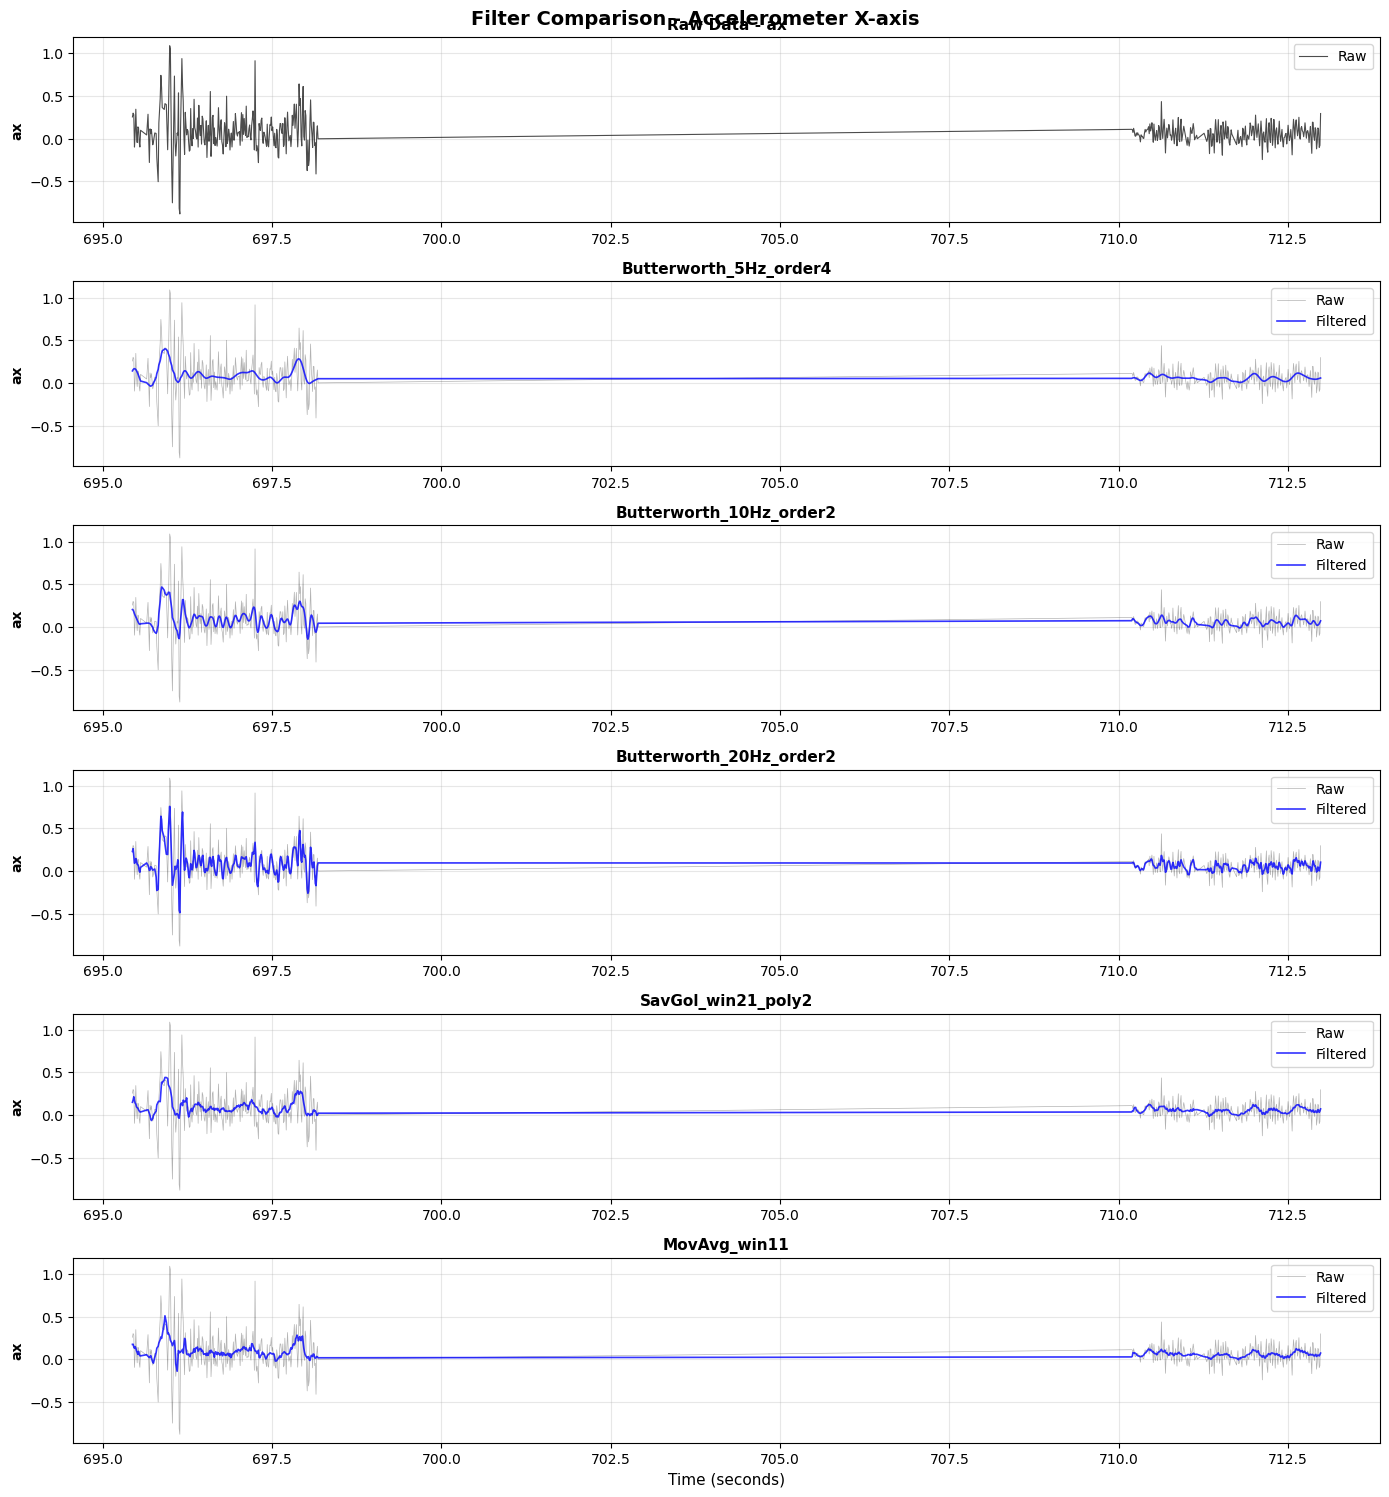

In [16]:
# Compare selected filters for accelerometer X-axis
selected_filters = [
    'Butterworth_5Hz_order4',
    'Butterworth_10Hz_order2',
    'Butterworth_20Hz_order2',
    'SavGol_win21_poly2',
    'MovAvg_win11'
]

fig = plot_filter_comparison_timeseries(
    df, 
    filtered_datasets, 
    viz_segment.index, 
    'ax', 
    selected_filters
)
fig.suptitle('Filter Comparison - Accelerometer X-axis', fontsize=14, fontweight='bold', y=0.995)
plt.show()

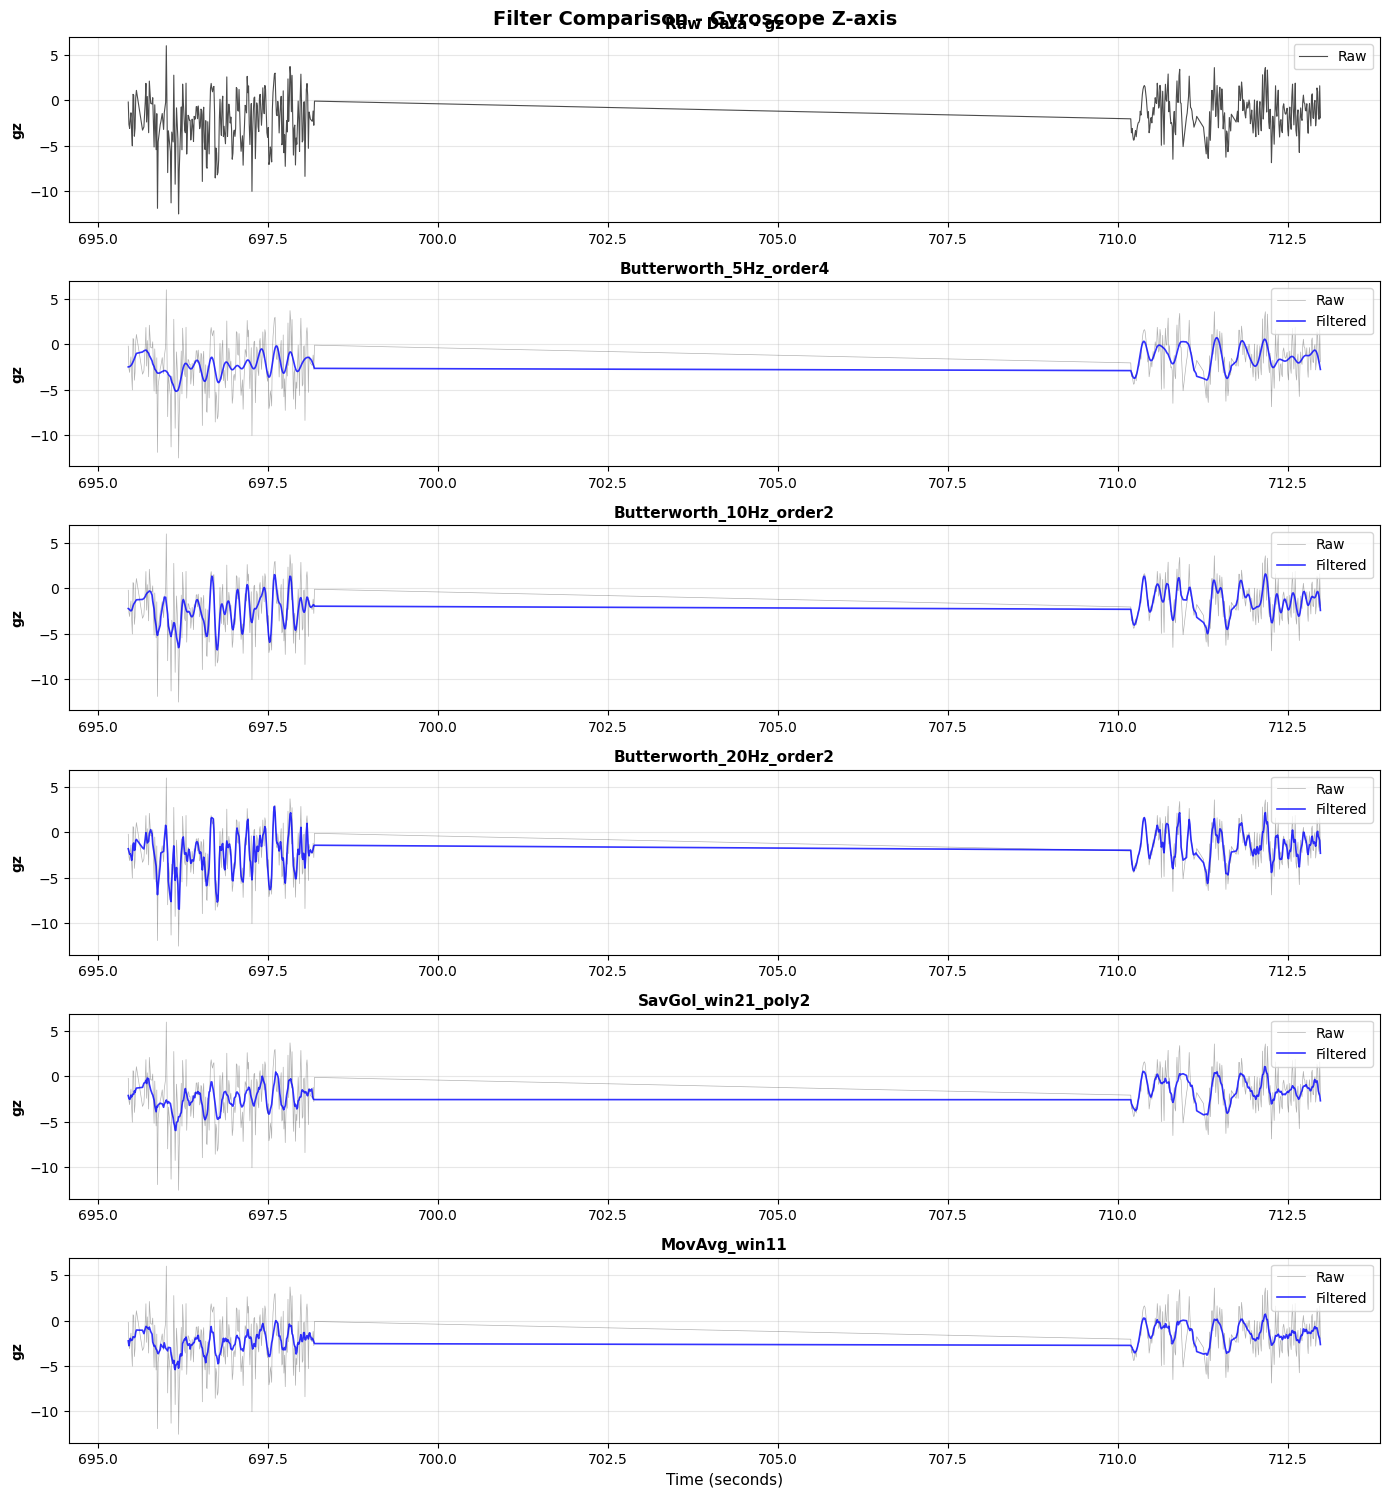

In [17]:
# Compare filters for gyroscope Z-axis
fig = plot_filter_comparison_timeseries(
    df, 
    filtered_datasets, 
    viz_segment.index, 
    'gz', 
    selected_filters
)
fig.suptitle('Filter Comparison - Gyroscope Z-axis', fontsize=14, fontweight='bold', y=0.995)
plt.show()

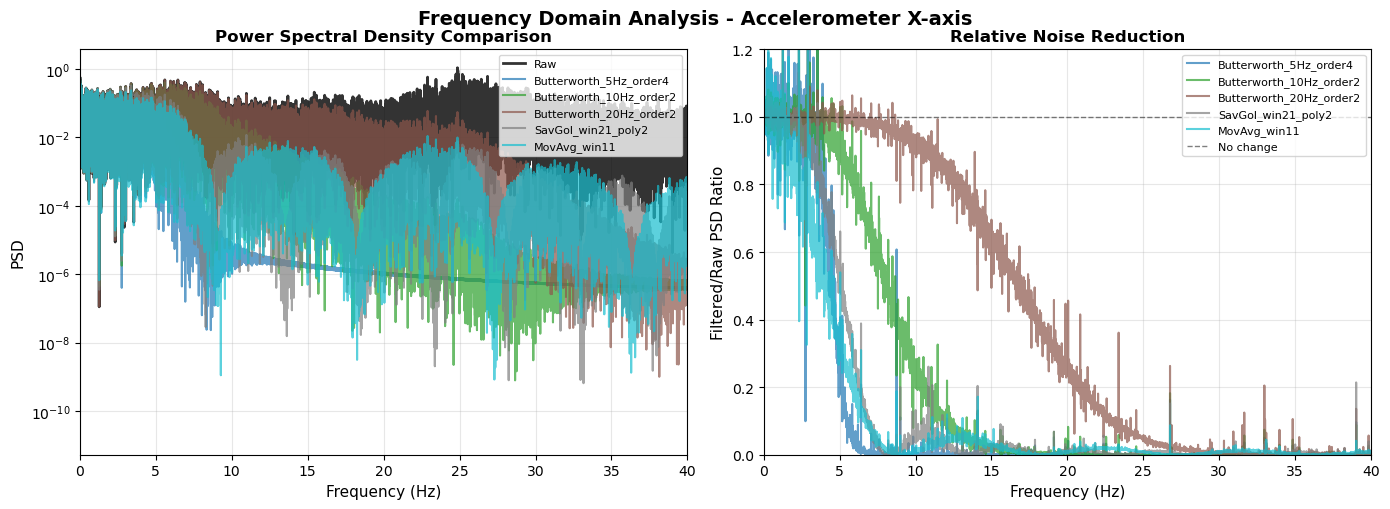

In [18]:
# Frequency domain comparison
def plot_frequency_comparison(df_raw, filtered_datasets, sensor_col, filter_names, sample_rate):
    """
    Compare frequency content of raw vs filtered data.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Compute PSD for raw data
    raw_signal = df_raw[sensor_col].values
    freqs_raw, psd_raw = compute_psd(raw_signal, sample_rate)
    
    # Left plot: All PSDs overlaid
    ax = axes[0]
    ax.semilogy(freqs_raw, psd_raw, 'k-', linewidth=2, alpha=0.8, label='Raw')
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(filter_names)))
    for filter_name, color in zip(filter_names, colors):
        filtered_signal = filtered_datasets[filter_name][sensor_col].values
        freqs, psd = compute_psd(filtered_signal, sample_rate)
        ax.semilogy(freqs, psd, linewidth=1.5, alpha=0.7, label=filter_name, color=color)
    
    ax.set_xlabel('Frequency (Hz)', fontsize=11)
    ax.set_ylabel('PSD', fontsize=11)
    ax.set_title('Power Spectral Density Comparison', fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 40])
    
    # Right plot: Noise reduction (ratio of filtered/raw PSD)
    ax = axes[1]
    for filter_name, color in zip(filter_names, colors):
        filtered_signal = filtered_datasets[filter_name][sensor_col].values
        freqs, psd = compute_psd(filtered_signal, sample_rate)
        
        # Interpolate to match frequencies
        psd_ratio = np.interp(freqs_raw, freqs, psd) / psd_raw
        ax.plot(freqs_raw, psd_ratio, linewidth=1.5, alpha=0.7, label=filter_name, color=color)
    
    ax.axhline(1.0, color='k', linestyle='--', linewidth=1, alpha=0.5, label='No change')
    ax.set_xlabel('Frequency (Hz)', fontsize=11)
    ax.set_ylabel('Filtered/Raw PSD Ratio', fontsize=11)
    ax.set_title('Relative Noise Reduction', fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 40])
    ax.set_ylim([0, 1.2])
    
    plt.tight_layout()
    return fig

fig = plot_frequency_comparison(df, filtered_datasets, 'ax', selected_filters, SAMPLE_RATE)
fig.suptitle(f'Frequency Domain Analysis - Accelerometer X-axis', fontsize=14, fontweight='bold', y=1.01)
plt.show()

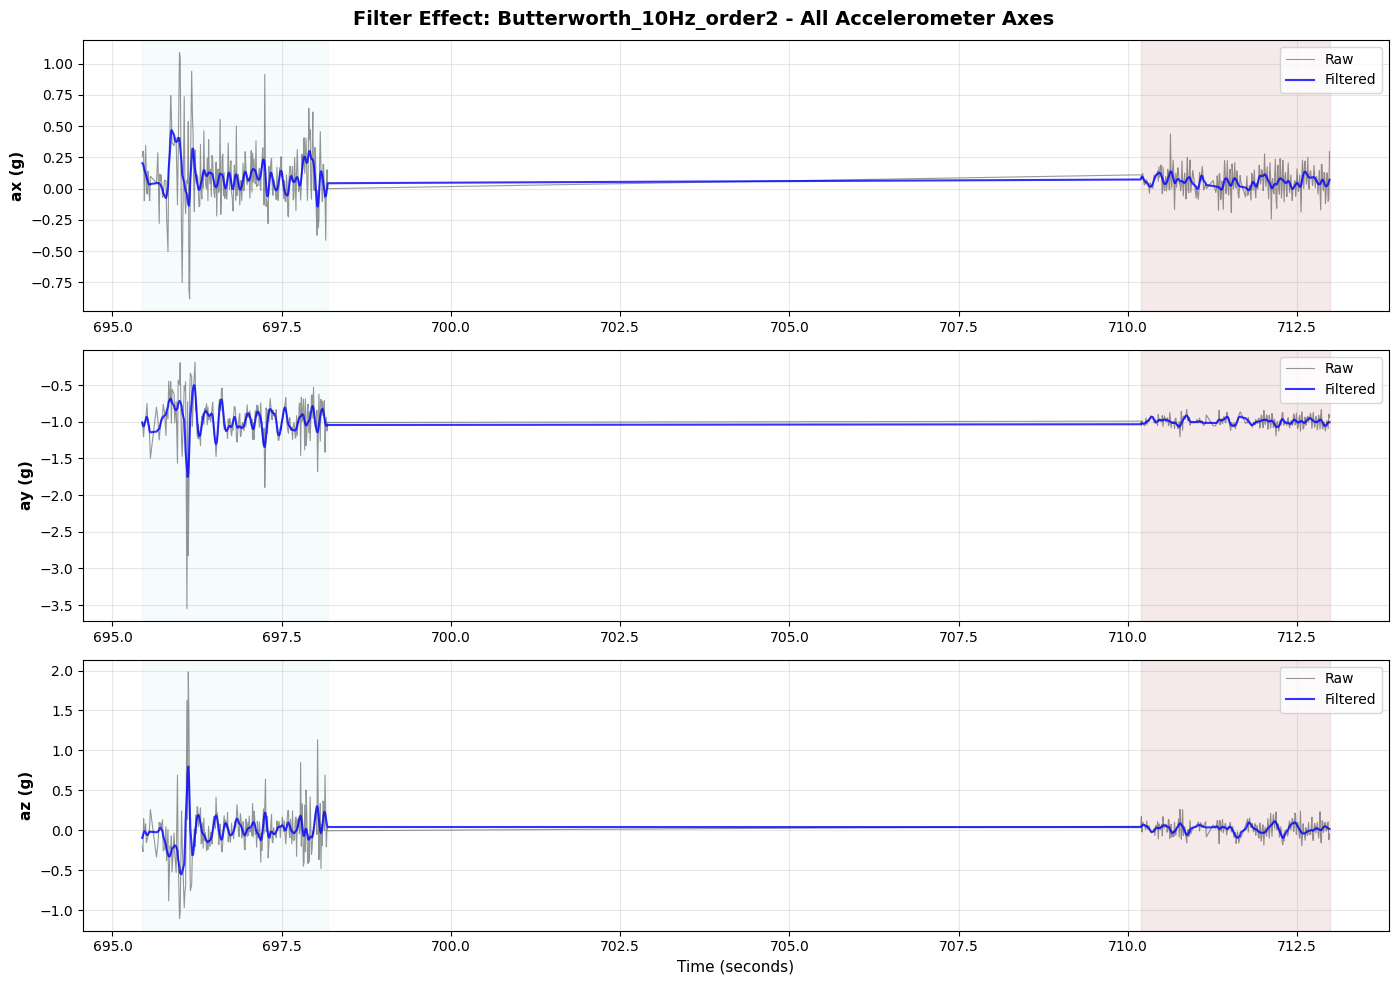

In [19]:
# Visualize effect on all accelerometer axes for ONE selected filter
best_filter_candidate = 'Butterworth_10Hz_order2'  # We'll update this after analysis

fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle(f'Filter Effect: {best_filter_candidate} - All Accelerometer Axes', 
             fontsize=14, fontweight='bold')

raw_segment = df.loc[viz_segment.index].copy()
filtered_segment = filtered_datasets[best_filter_candidate].loc[viz_segment.index].copy()
t_rel = raw_segment['t_rel'].values

for idx, col in enumerate(['ax', 'ay', 'az']):
    ax = axes[idx]
    ax.plot(t_rel, raw_segment[col].values, 'k-', linewidth=0.8, alpha=0.4, label='Raw')
    ax.plot(t_rel, filtered_segment[col].values, 'b-', linewidth=1.5, alpha=0.8, label='Filtered')
    
    ax.set_ylabel(f'{col} (g)', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=10)
    
    # Add label background colors
    for label in raw_segment['label'].unique():
        if pd.notna(label):
            label_mask = raw_segment['label'] == label
            label_segments = raw_segment[label_mask]
            if len(label_segments) > 0:
                t_min = label_segments['t_rel'].min()
                t_max = label_segments['t_rel'].max()
                color_map = {'grass': 'green', 'muddy_dirt_track': 'brown', 'smooth_terrain': 'lightblue'}
                color = color_map.get(label, 'gray')
                ax.axvspan(t_min, t_max, alpha=0.1, color=color, label=label if idx == 0 else '')

axes[-1].set_xlabel('Time (seconds)', fontsize=11)
plt.tight_layout()
plt.show()

## 5. Quantitative Filter Comparison

Let's compute some metrics to help select the best filter:
1. **Signal-to-Noise Ratio (SNR)**: Ratio of signal variance to high-frequency noise variance
2. **Smoothness**: Standard deviation of the derivative (lower = smoother)
3. **Signal preservation**: Correlation with raw signal (higher = better preservation)

In [21]:
def compute_filter_metrics(raw_signal, filtered_signal, sample_rate):
    """
    Compute quality metrics for a filtered signal.
    
    Returns:
        dict with metrics
    """
    # 1. Correlation with raw signal
    correlation = np.corrcoef(raw_signal, filtered_signal)[0, 1]
    
    # 2. Smoothness (lower derivative std = smoother)
    raw_derivative = np.diff(raw_signal)
    filtered_derivative = np.diff(filtered_signal)
    smoothness_improvement = np.std(raw_derivative) / np.std(filtered_derivative)
    
    # 3. High-frequency noise reduction
    # Estimate noise as high-frequency component
    freqs, psd_raw = compute_psd(raw_signal, sample_rate)
    _, psd_filtered = compute_psd(filtered_signal, sample_rate)
    
    # Noise is power above 15 Hz
    high_freq_mask = freqs > 15
    if np.sum(high_freq_mask) > 0:
        noise_raw = np.sum(psd_raw[high_freq_mask])
        noise_filtered = np.sum(psd_filtered[high_freq_mask])
        noise_reduction = noise_raw / (noise_filtered + 1e-10)  # Avoid division by zero
    else:
        noise_reduction = 1.0
    
    # 4. RMS of residual (difference between raw and filtered)
    residual = raw_signal - filtered_signal
    rms_residual = np.sqrt(np.mean(residual**2))
    
    return {
        'correlation': correlation,
        'smoothness_improvement': smoothness_improvement,
        'noise_reduction': noise_reduction,
        'rms_residual': rms_residual
    }


# Compute metrics for all filters
print("Computing metrics for all filters...")
metrics_results = []

for filter_name, df_filtered in filtered_datasets.items():
    filter_metrics = {'filter_name': filter_name}
    
    # Average metrics across all sensor columns
    for sensor_col in all_sensor_cols:
        raw_signal = df[sensor_col].values
        filtered_signal = df_filtered[sensor_col].values
        
        metrics = compute_filter_metrics(raw_signal, filtered_signal, SAMPLE_RATE)
        
        for metric_name, value in metrics.items():
            key = f'{sensor_col}_{metric_name}'
            filter_metrics[key] = value
    
    # Compute average across all sensors
    filter_metrics['avg_correlation'] = np.mean([filter_metrics[f'{col}_correlation'] for col in all_sensor_cols])
    filter_metrics['avg_smoothness_improvement'] = np.mean([filter_metrics[f'{col}_smoothness_improvement'] for col in all_sensor_cols])
    filter_metrics['avg_noise_reduction'] = np.mean([filter_metrics[f'{col}_noise_reduction'] for col in all_sensor_cols])
    filter_metrics['avg_rms_residual'] = np.mean([filter_metrics[f'{col}_rms_residual'] for col in all_sensor_cols])
    
    metrics_results.append(filter_metrics)

metrics_df = pd.DataFrame(metrics_results)
print("✓ Metrics computed!")

Computing metrics for all filters...
✓ Metrics computed!


In [22]:
# Display metrics summary
summary_cols = ['filter_name', 'avg_correlation', 'avg_smoothness_improvement', 
                'avg_noise_reduction', 'avg_rms_residual']
metrics_summary = metrics_df[summary_cols].copy()

# Sort by different criteria
print("=" * 80)
print("FILTER PERFORMANCE METRICS")
print("=" * 80)
print()

print("📊 All Filters - Summary Metrics")
print("-" * 80)
print(metrics_summary.to_string(index=False))
print()

print("🏆 Top 5 by Signal Preservation (highest correlation):")
print(metrics_summary.nlargest(5, 'avg_correlation')[['filter_name', 'avg_correlation']].to_string(index=False))
print()

print("🏆 Top 5 by Smoothness (highest smoothness improvement):")
print(metrics_summary.nlargest(5, 'avg_smoothness_improvement')[['filter_name', 'avg_smoothness_improvement']].to_string(index=False))
print()

print("🏆 Top 5 by Noise Reduction (highest noise reduction):")
print(metrics_summary.nlargest(5, 'avg_noise_reduction')[['filter_name', 'avg_noise_reduction']].to_string(index=False))
print()

print("🏆 Top 5 by Low Residual (smallest difference from raw):")
print(metrics_summary.nsmallest(5, 'avg_rms_residual')[['filter_name', 'avg_rms_residual']].to_string(index=False))

FILTER PERFORMANCE METRICS

📊 All Filters - Summary Metrics
--------------------------------------------------------------------------------
            filter_name  avg_correlation  avg_smoothness_improvement  avg_noise_reduction  avg_rms_residual
 Butterworth_5Hz_order2         0.791873                    9.587230         22462.891822          0.532484
 Butterworth_5Hz_order4         0.761141                    9.592214         42543.419017          0.554926
Butterworth_10Hz_order2         0.862881                    4.957599           644.711418          0.390741
Butterworth_10Hz_order4         0.853026                    4.701321         10139.801664          0.398557
Butterworth_20Hz_order2         0.918852                    2.933105            13.651116          0.292380
     SavGol_win11_poly2         0.849706                    3.869387            56.302395          0.397753
     SavGol_win21_poly2         0.787725                    6.525431           140.173103          0.51

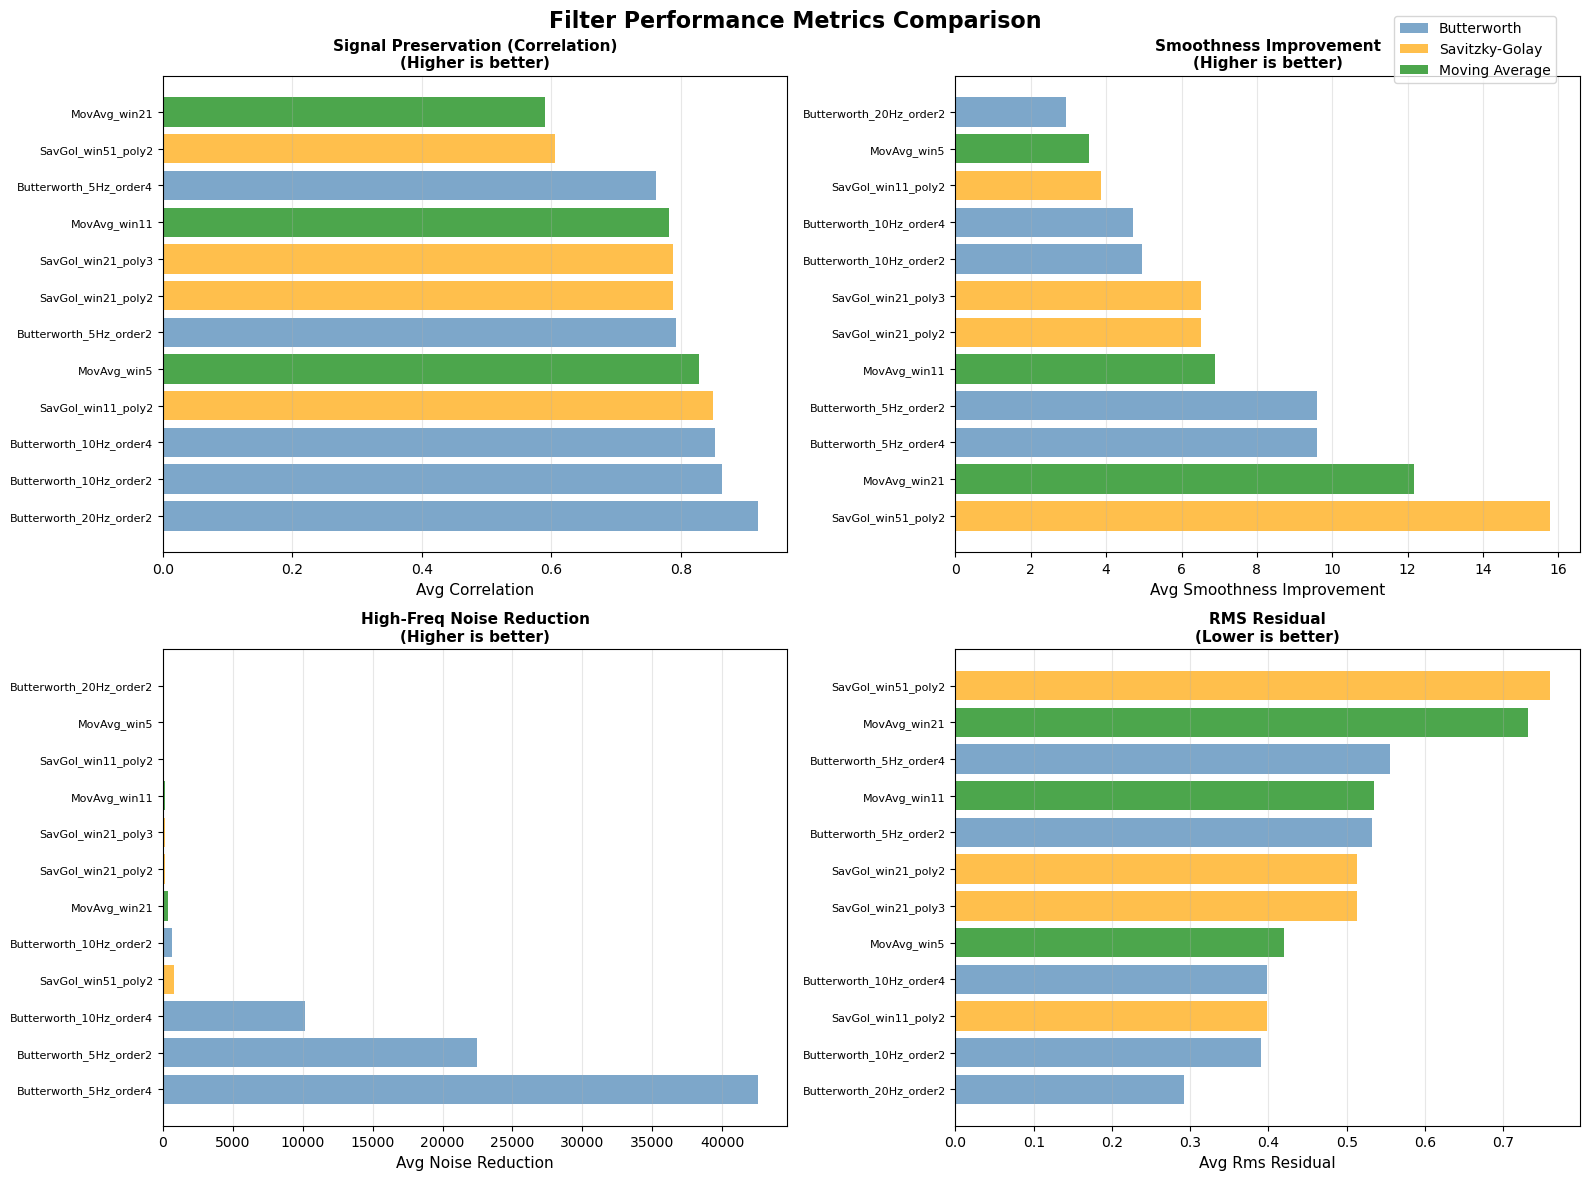

In [23]:
# Visualize metrics
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Filter Performance Metrics Comparison', fontsize=16, fontweight='bold')

metrics_to_plot = [
    ('avg_correlation', 'Signal Preservation (Correlation)', 'Higher is better'),
    ('avg_smoothness_improvement', 'Smoothness Improvement', 'Higher is better'),
    ('avg_noise_reduction', 'High-Freq Noise Reduction', 'Higher is better'),
    ('avg_rms_residual', 'RMS Residual', 'Lower is better')
]

for idx, (metric, title, note) in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    
    # Sort by metric value
    sorted_data = metrics_summary.sort_values(metric, ascending=(metric == 'avg_rms_residual'))
    
    # Color bars by filter type
    colors = []
    for name in sorted_data['filter_name']:
        if 'Butterworth' in name:
            colors.append('steelblue')
        elif 'SavGol' in name:
            colors.append('orange')
        else:
            colors.append('green')
    
    bars = ax.barh(range(len(sorted_data)), sorted_data[metric], color=colors, alpha=0.7)
    ax.set_yticks(range(len(sorted_data)))
    ax.set_yticklabels(sorted_data['filter_name'], fontsize=8)
    ax.set_xlabel(metric.replace('_', ' ').title(), fontsize=11)
    ax.set_title(f'{title}\n({note})', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', alpha=0.7, label='Butterworth'),
    Patch(facecolor='orange', alpha=0.7, label='Savitzky-Golay'),
    Patch(facecolor='green', alpha=0.7, label='Moving Average')
]
fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.98, 0.98), fontsize=10)

plt.tight_layout()
plt.show()

## 6. Filter Selection

Based on the visual and quantitative evaluation, let's select the best filter(s) for our terrain analysis task.

**Selection Criteria:**
1. **High correlation** (>0.95): Preserves signal characteristics
2. **Significant noise reduction** (>2x): Reduces high-frequency noise
3. **Moderate smoothness**: Not too aggressive (diminishing returns)
4. **Visual quality**: Clear terrain patterns without over-smoothing

In [24]:
# Apply selection criteria
good_filters = metrics_summary[
    (metrics_summary['avg_correlation'] > 0.95) &
    (metrics_summary['avg_noise_reduction'] > 2.0)
].copy()

print("Filters meeting quality criteria (correlation > 0.95, noise reduction > 2.0):")
print("=" * 80)
print(good_filters.to_string(index=False))
print()

# Rank by balanced score
# Score = correlation * noise_reduction * smoothness_improvement / rms_residual
good_filters['composite_score'] = (
    good_filters['avg_correlation'] * 
    good_filters['avg_noise_reduction'] * 
    good_filters['avg_smoothness_improvement'] / 
    (good_filters['avg_rms_residual'] + 0.01)  # Avoid division by zero
)

good_filters = good_filters.sort_values('composite_score', ascending=False)

print("\n🏆 Top Recommended Filters (by composite score):")
print("=" * 80)
print(good_filters[['filter_name', 'composite_score', 'avg_correlation', 
                     'avg_noise_reduction']].to_string(index=False))

if len(good_filters) > 0:
    best_filter_name = good_filters.iloc[0]['filter_name']
    print(f"\n✅ RECOMMENDED FILTER: {best_filter_name}")
    print()
    
    # Get filter config
    best_config = next(cfg for cfg in filter_configs if cfg['name'] == best_filter_name)
    print(f"Description: {best_config['description']}")
    print(f"Parameters: {best_config['params']}")
else:
    print("\n⚠️  No filters met the strict criteria. Consider relaxing thresholds or choosing manually.")
    best_filter_name = metrics_summary.nlargest(1, 'avg_correlation').iloc[0]['filter_name']
    print(f"Fallback recommendation (best correlation): {best_filter_name}")

Filters meeting quality criteria (correlation > 0.95, noise reduction > 2.0):
Empty DataFrame
Columns: [filter_name, avg_correlation, avg_smoothness_improvement, avg_noise_reduction, avg_rms_residual]
Index: []


🏆 Top Recommended Filters (by composite score):
Empty DataFrame
Columns: [filter_name, composite_score, avg_correlation, avg_noise_reduction]
Index: []

⚠️  No filters met the strict criteria. Consider relaxing thresholds or choosing manually.
Fallback recommendation (best correlation): Butterworth_20Hz_order2


## 7. Save Filtered Dataset

Save the best-performing filtered dataset for use in downstream notebooks (05_windowing, 06_features, 07_models).

In [ ]:
# Select which filter to save (change this after reviewing results)
filter_to_save = best_filter_name  # Or manually specify: 'Butterworth_10Hz_order2'

print(f"Saving filtered dataset: {filter_to_save}")
print()

# Get the filtered dataset
df_to_save = filtered_datasets[filter_to_save].copy()

# Create output directory
output_dir = PROJECT_ROOT / "data" / "interim" / "filtered"
output_dir.mkdir(parents=True, exist_ok=True)

# Save as CSV
output_path = output_dir / "filtered_dataset.csv"
df_to_save.to_csv(output_path, index=False)

print(f"✓ Saved filtered dataset to: {output_path}")
print(f"  Shape: {df_to_save.shape}")
print(f"  Columns: {list(df_to_save.columns)}")
print()

# Save filter metadata
metadata = {
    'filter_name': filter_to_save,
    'filter_config': next(cfg for cfg in filter_configs if cfg['name'] == filter_to_save),
    'source_file': str(cleaned_path),
    'output_file': str(output_path),
    'num_samples': len(df_to_save),
    'num_runs': df_to_save['run_id'].nunique(),
    'sampling_rate_hz': SAMPLE_RATE,
    'filtered_columns': all_sensor_cols,
    'metrics': metrics_summary[metrics_summary['filter_name'] == filter_to_save].iloc[0].to_dict()
}

import json
metadata_path = output_dir / "filter_metadata.json"
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2, default=str)

print(f"✓ Saved filter metadata to: {metadata_path}")
print()
print("=" * 80)
print("FILTERING COMPLETE!")
print("=" * 80)
print()
print("Next steps:")
print("  1. Review the visualizations and metrics above")
print("  2. If you want a different filter, change 'filter_to_save' and re-run this cell")
print("  3. Proceed to 05_windowing.ipynb to create fixed-length windows")
print("  4. The filtered dataset is ready at: data/interim/filtered/filtered_dataset.csv")

## 8. Summary

### What We Did
1. **Frequency Analysis**: Analyzed FFT/PSD to understand signal frequency content
2. **Filter Testing**: Applied 12 different filter configurations (Butterworth, Savitzky-Golay, Moving Average)
3. **Visual Evaluation**: Compared time-series and frequency domain for multiple filters
4. **Quantitative Metrics**: Computed correlation, smoothness, noise reduction, and residual metrics
5. **Filter Selection**: Identified best filter based on balanced performance criteria

### How to Interpret Results

**Good Filter Characteristics:**
- **Correlation > 0.95**: Preserves original signal features (terrain patterns)
- **Noise Reduction > 2**: Effectively reduces high-frequency noise
- **Smoothness Improvement > 1**: Makes signal smoother without over-filtering
- **Visual Test**: Filtered signal is smoother but retains terrain-specific variations

**Filter Type Trade-offs:**
- **Butterworth (low cutoff, high order)**: Aggressive smoothing, good for noisy sensors
- **Butterworth (high cutoff, low order)**: Gentle smoothing, preserves more detail
- **Savitzky-Golay**: Preserves peaks/valleys better, good for features
- **Moving Average**: Simple but can lag/blur sharp transitions

### Recommendations for Different Use Cases

**For Classification (Machine Learning):**
- Use moderate filtering (10-20 Hz Butterworth or SavGol_win21)
- Balance noise reduction with feature preservation
- Avoid over-smoothing (loses discriminative information)

**For Visualization:**
- Use aggressive filtering (5 Hz Butterworth) for cleaner plots
- Acceptable to sacrifice some detail for clarity

**For Real-time Application:**
- Moving Average or low-order Butterworth (computationally cheaper)
- SavGol requires storing entire window (more memory)

### Next Steps
After reviewing the results, proceed to [05_windowing.ipynb](05_windowing.ipynb) to create fixed-length windows for feature extraction.